Datasets nettoyés chargés :
  Bruteforce         → 5097 lignes, 45 colonnes
  DDoS               → 14292 lignes, 45 colonnes
  DoS                → 14121 lignes, 45 colonnes
  Evil               → 10 lignes, 45 colonnes
  Fakelanding        → 69 lignes, 45 colonnes
  MITM               → 208 lignes, 45 colonnes
  Normal             → 36806 lignes, 45 colonnes
  Reconnassiance     → 1152 lignes, 45 colonnes
  Reply              → 202 lignes, 45 colonnes
  Scanning           → 1152 lignes, 45 colonnes
  UAVIDS-2025        → 113952 lignes, 20 colonnes

  Bruteforce
Aucune colonne catégorielle
ACP normale        : 44 → 7 composantes (95% variance)

  DDoS
Aucune colonne catégorielle
ACP normale        : 44 → 4 composantes (95% variance)

  DoS
Aucune colonne catégorielle
ACP normale        : 44 → 5 composantes (95% variance)

  Evil
Aucune colonne catégorielle
ACP limitée        : 44 → 3 composantes (10 lignes)

  Fakelanding
Aucune colonne catégorielle
ACP normale        : 44 → 6 composan

C:\Users\skhabaz\AppData\Local\Temp\ipykernel_24652\1937711647.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_24652\1937711647.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/do

ACP normale        : 19 → 8 composantes (95% variance)


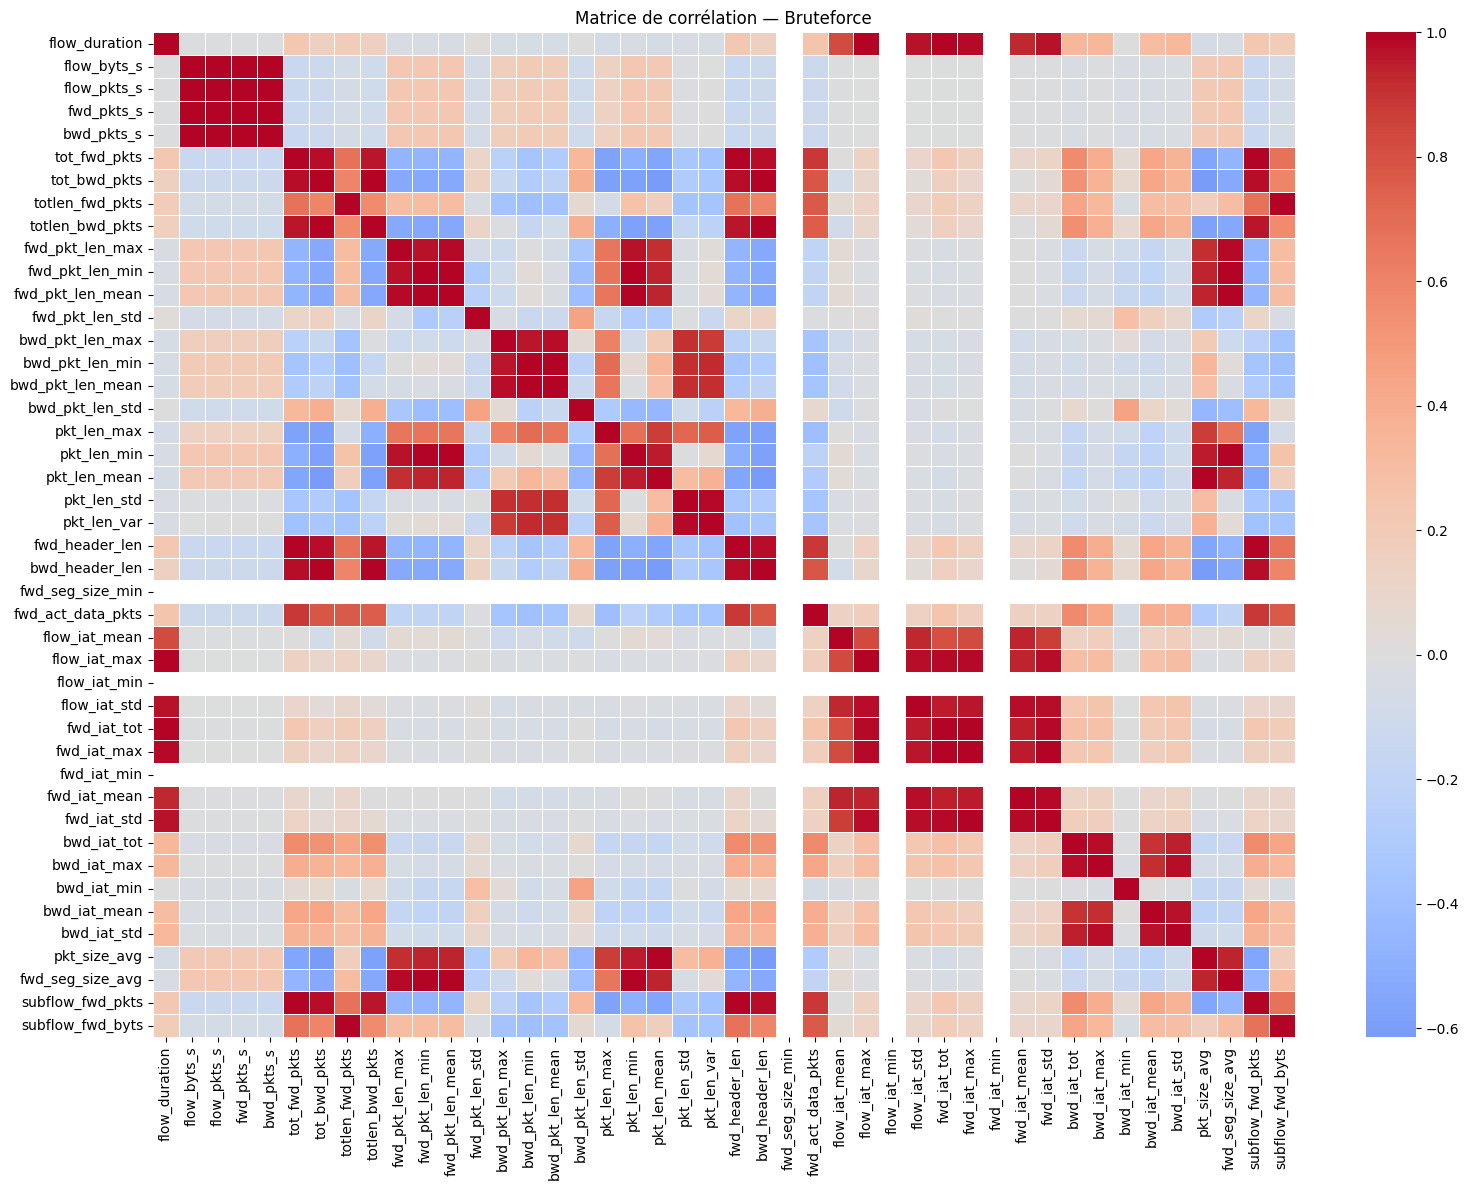

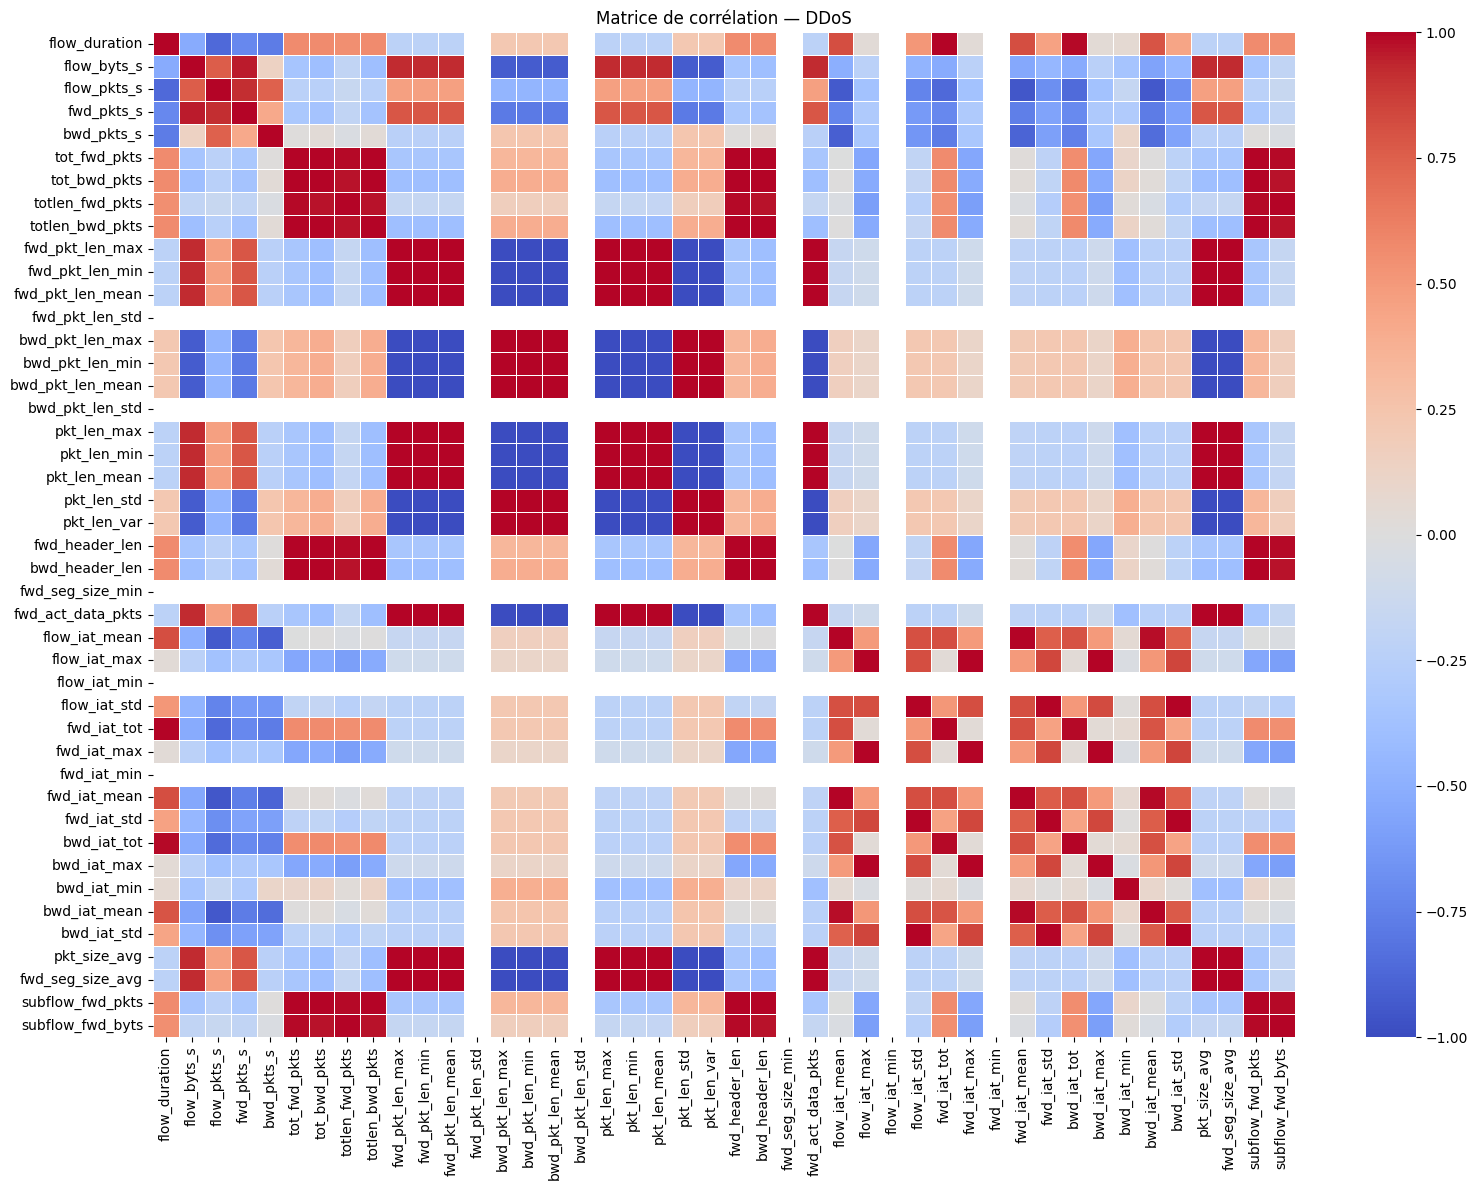

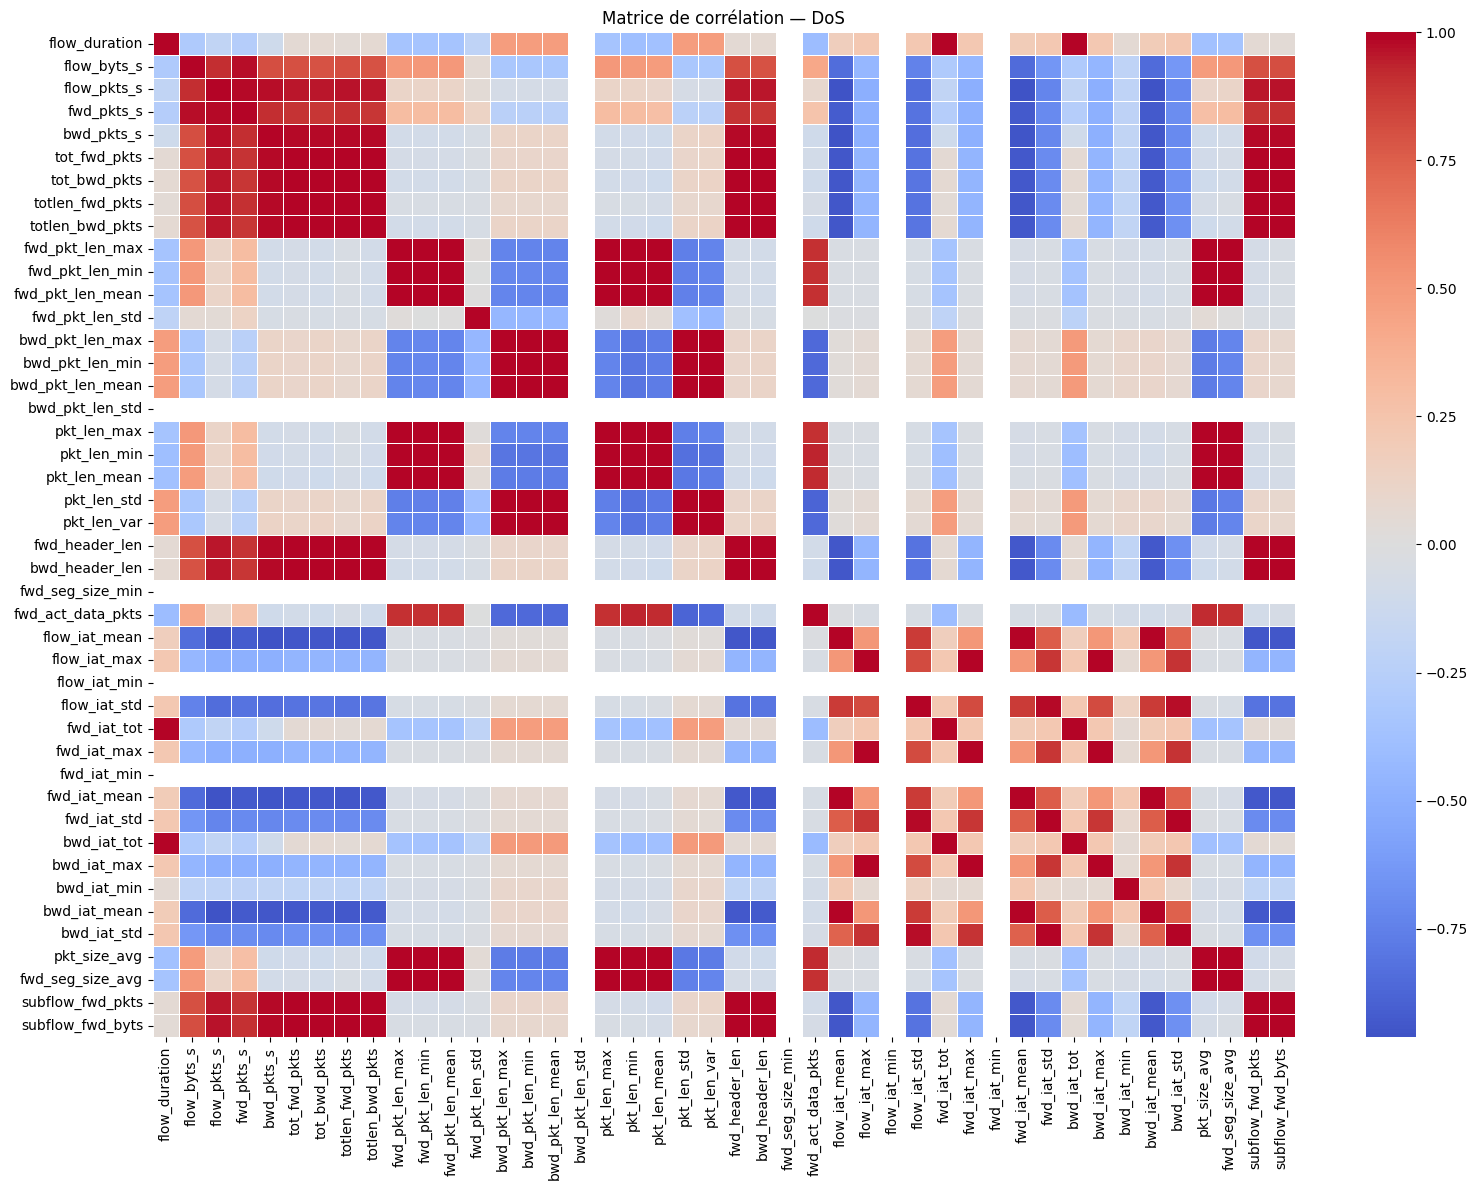

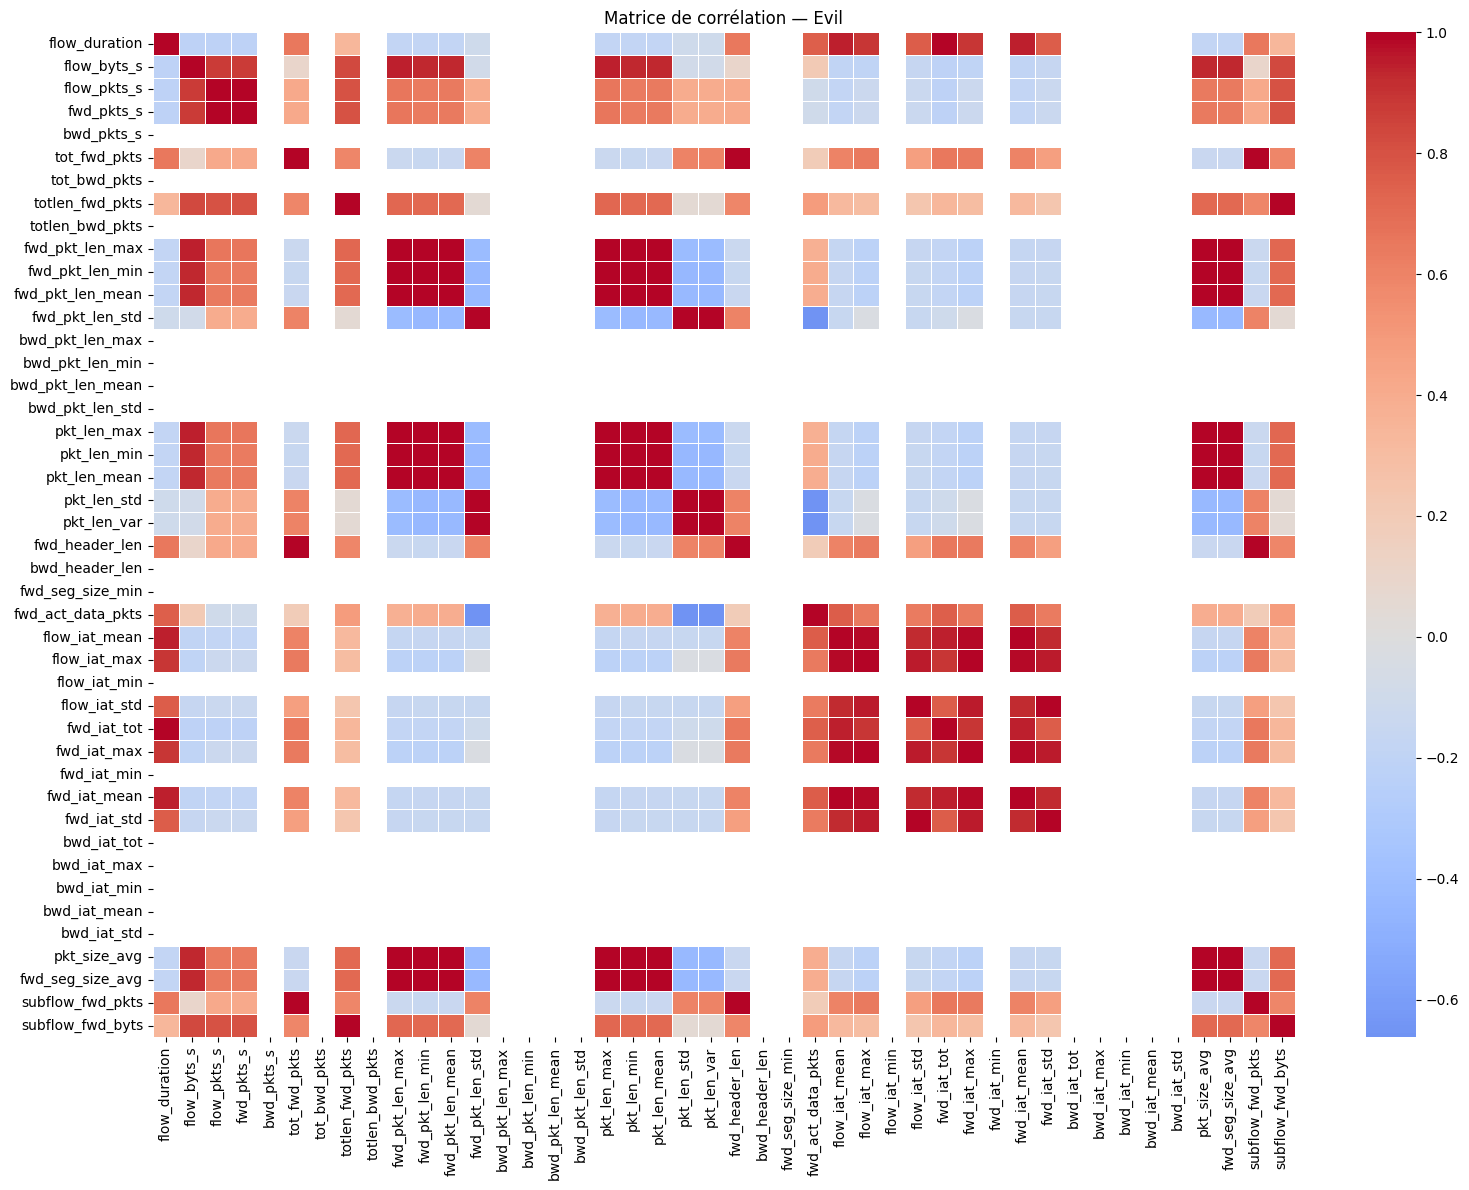

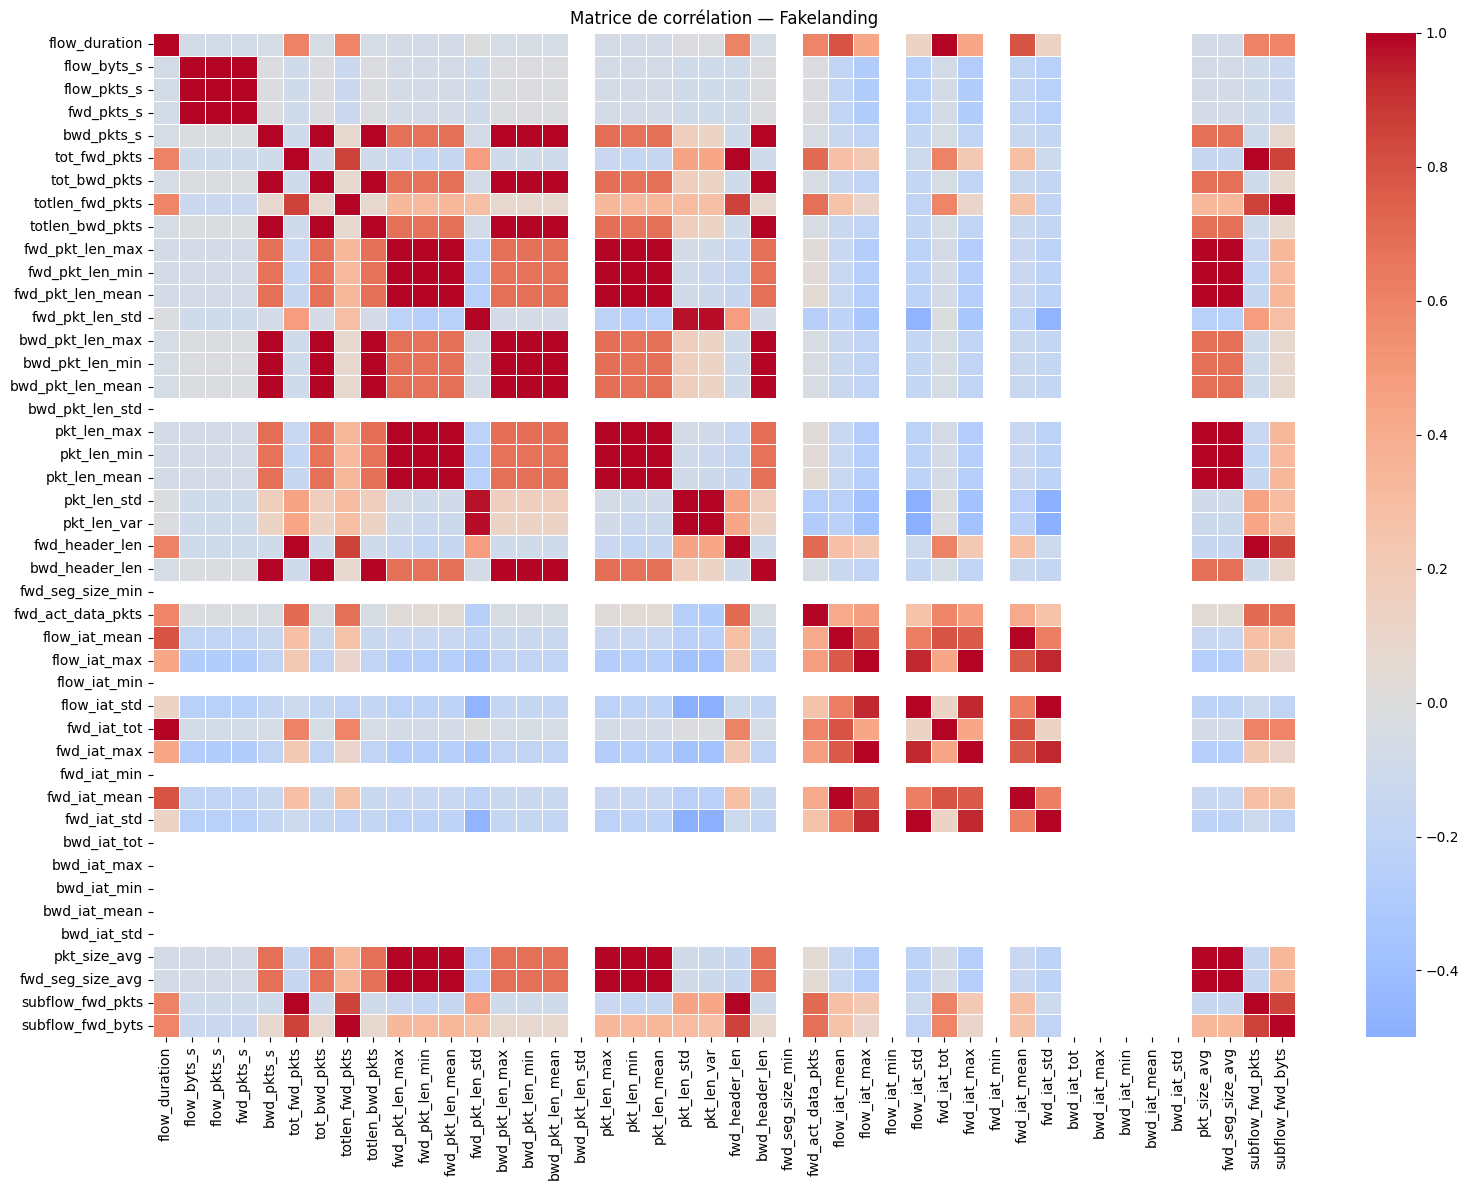

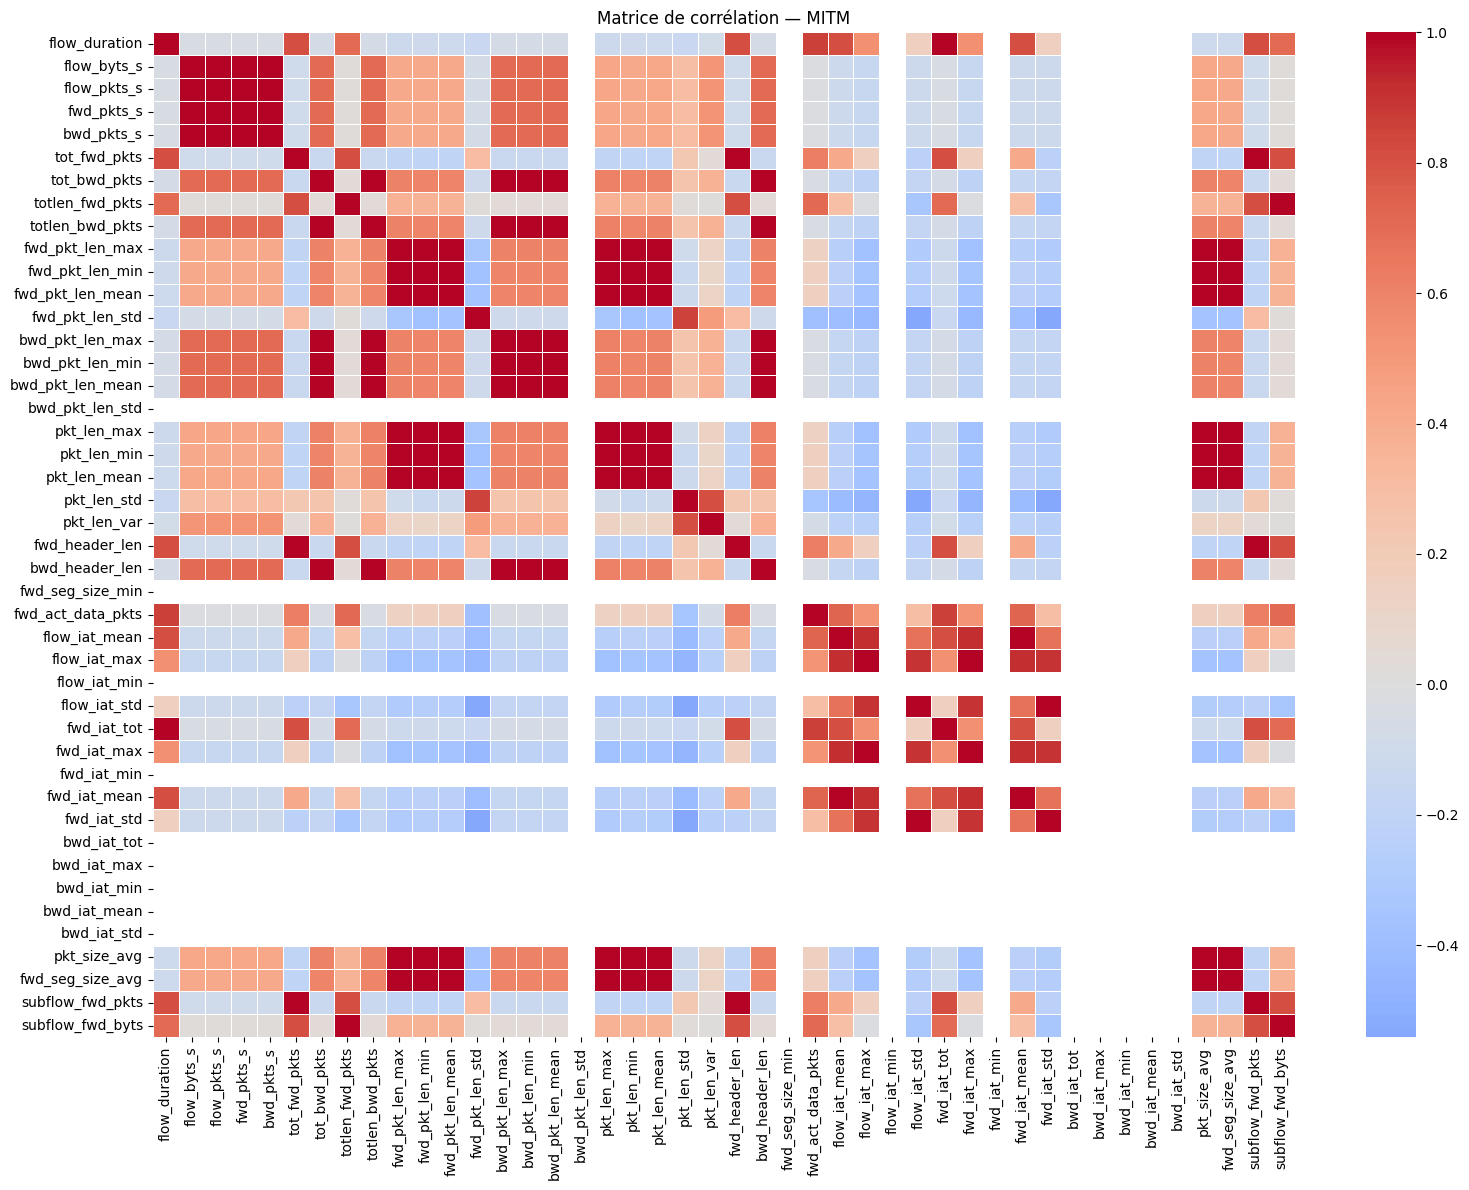

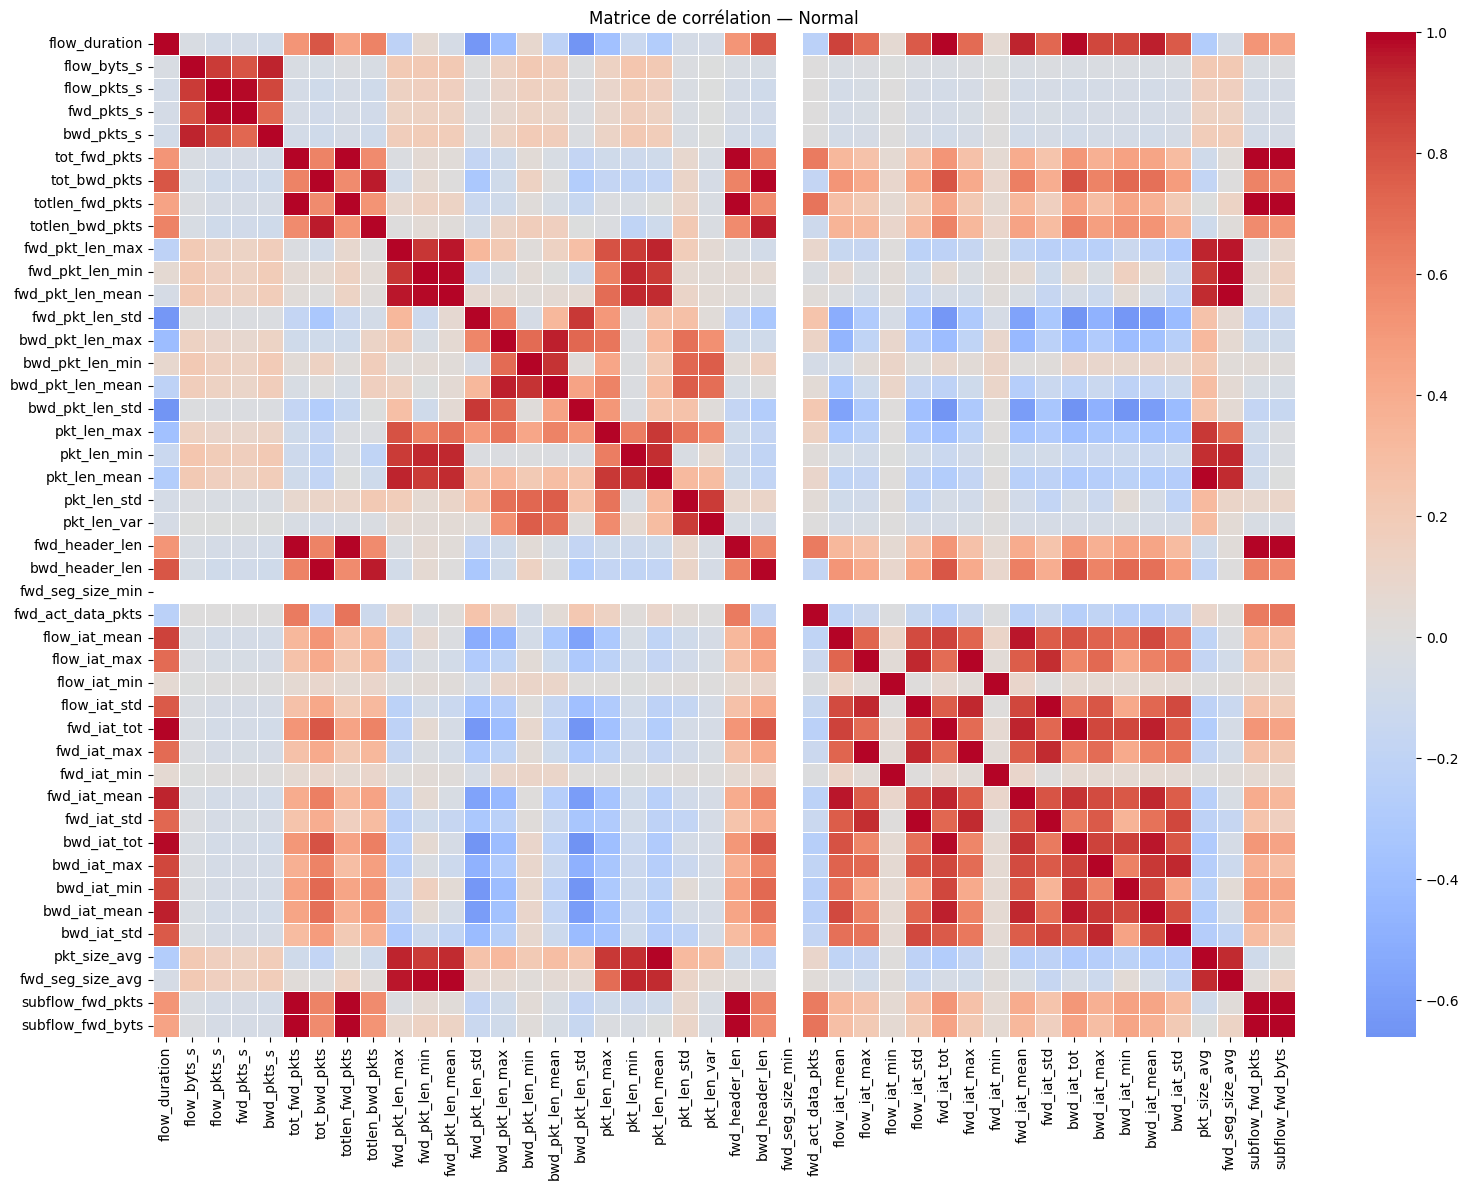

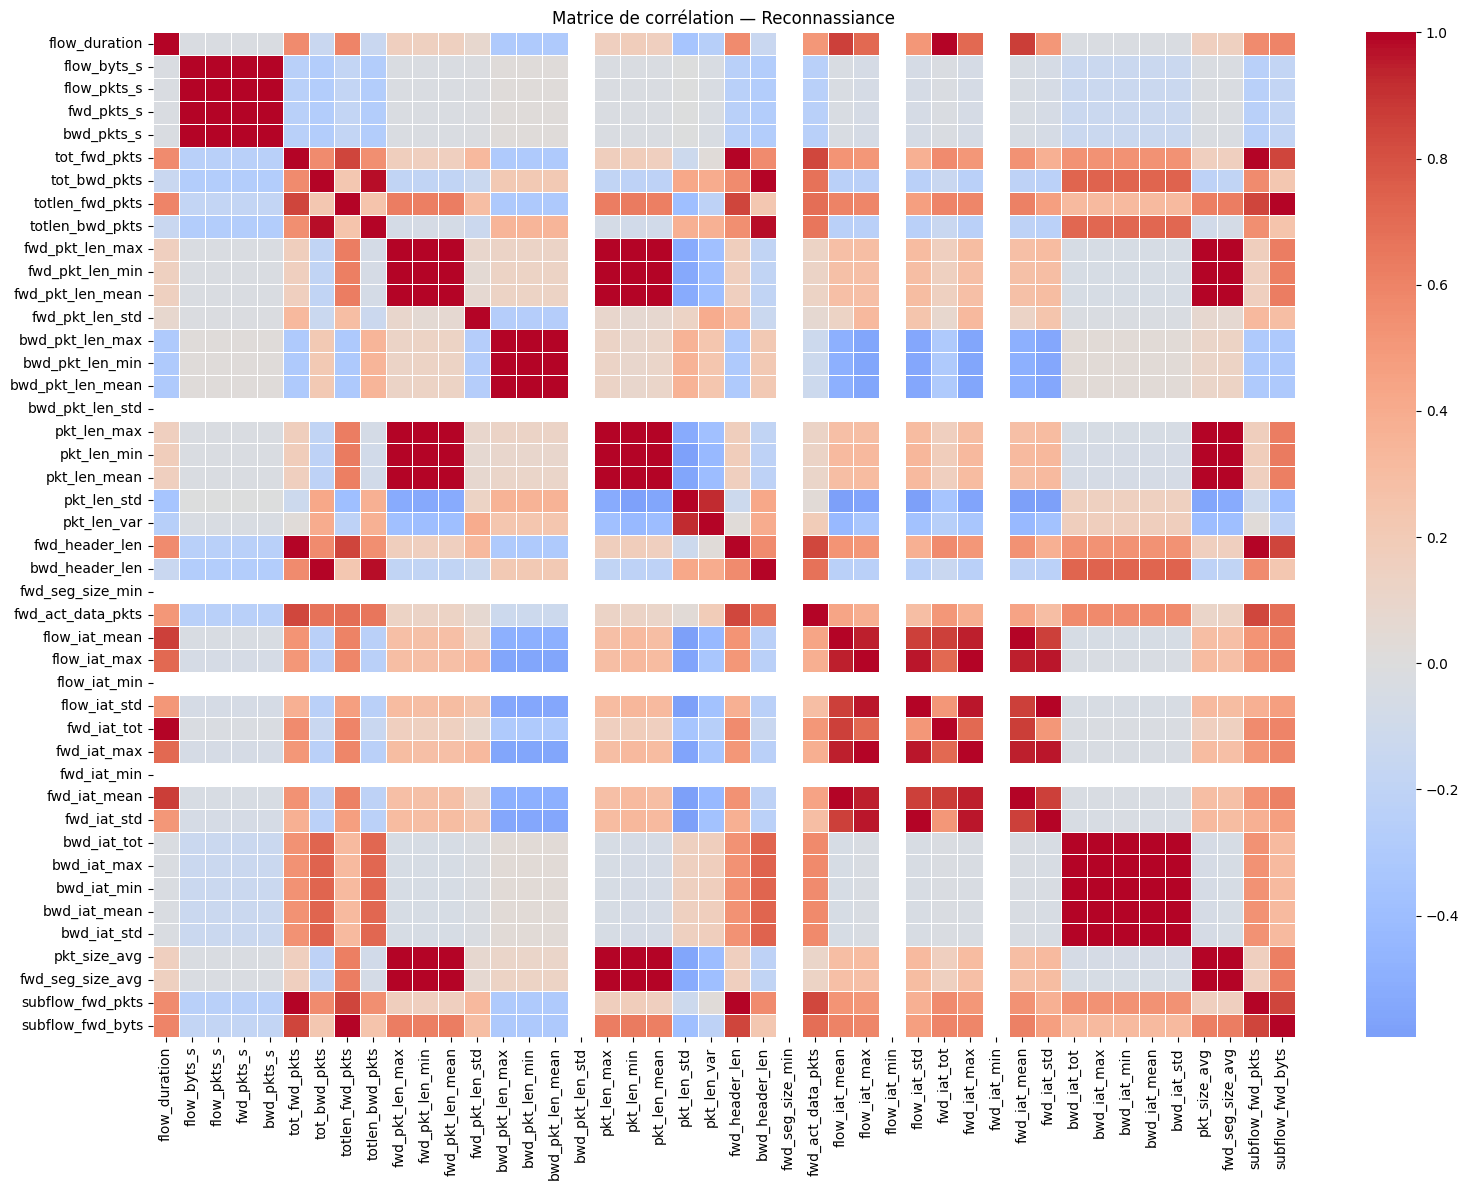

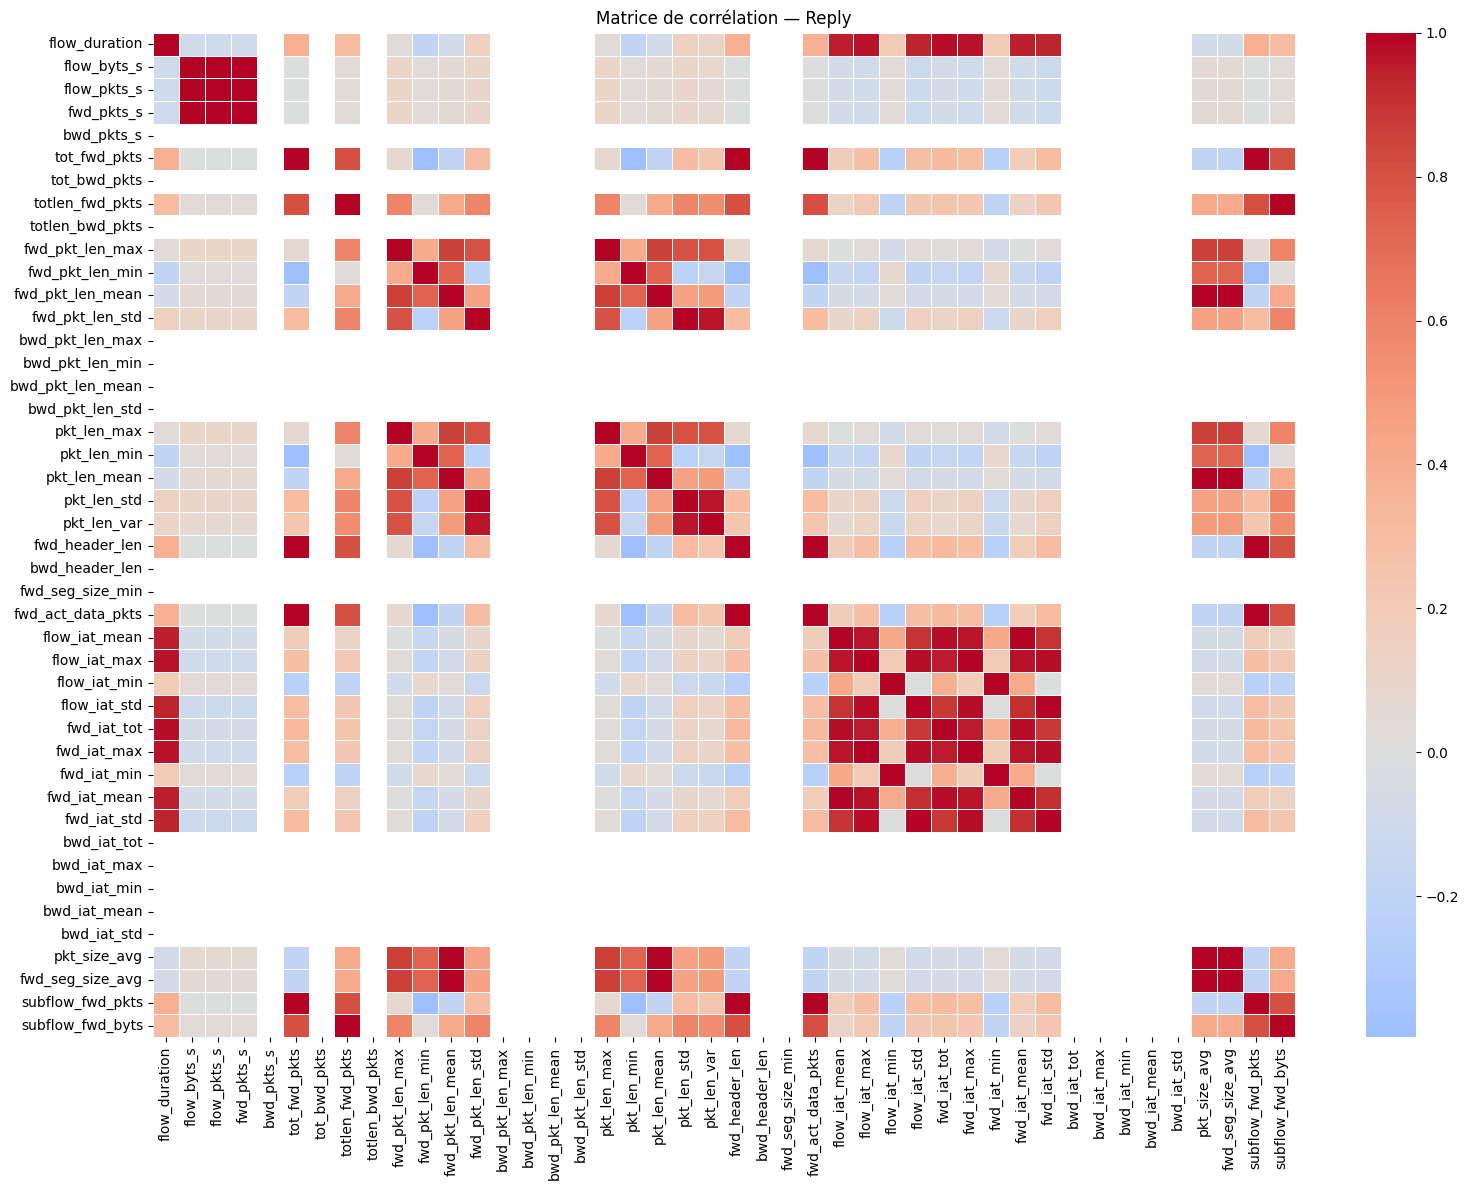

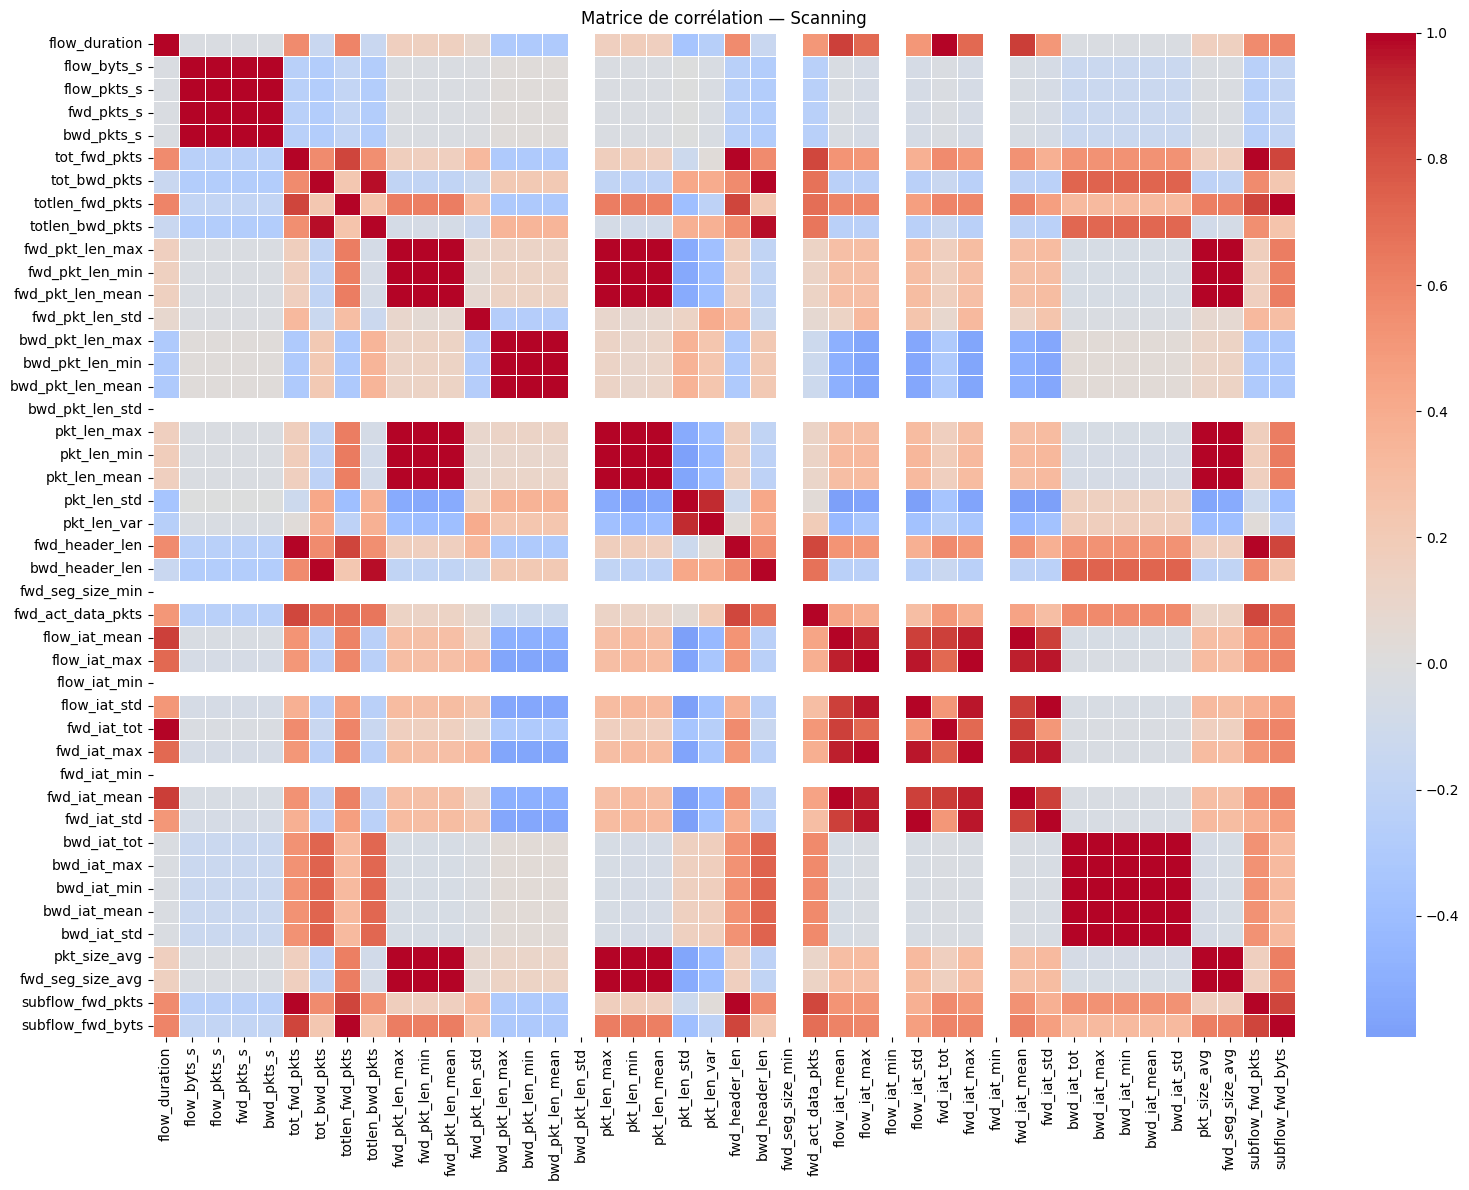

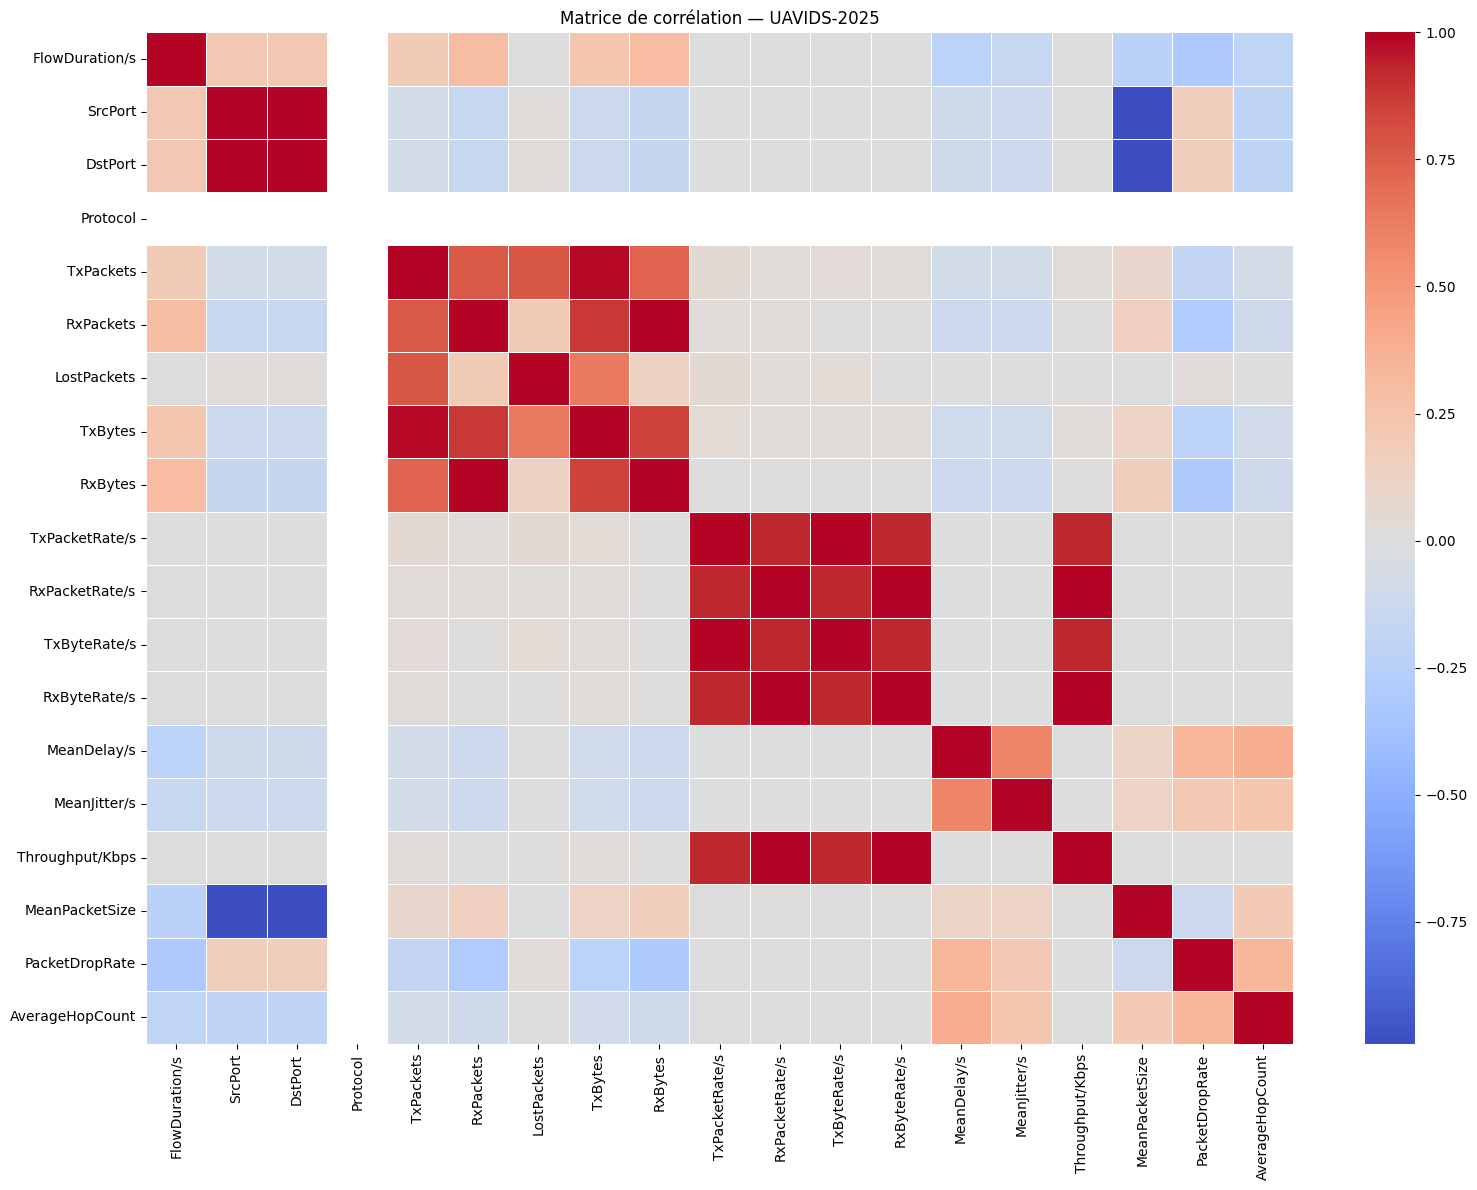

 Matrices de corrélation exportées pour tous les datasets


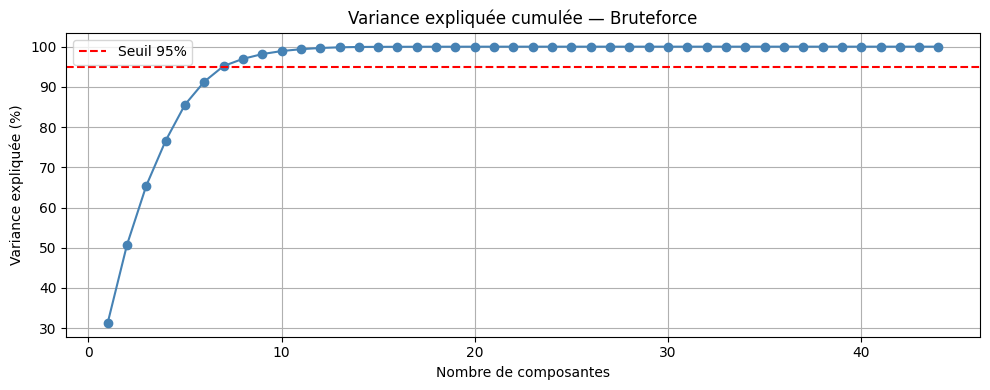

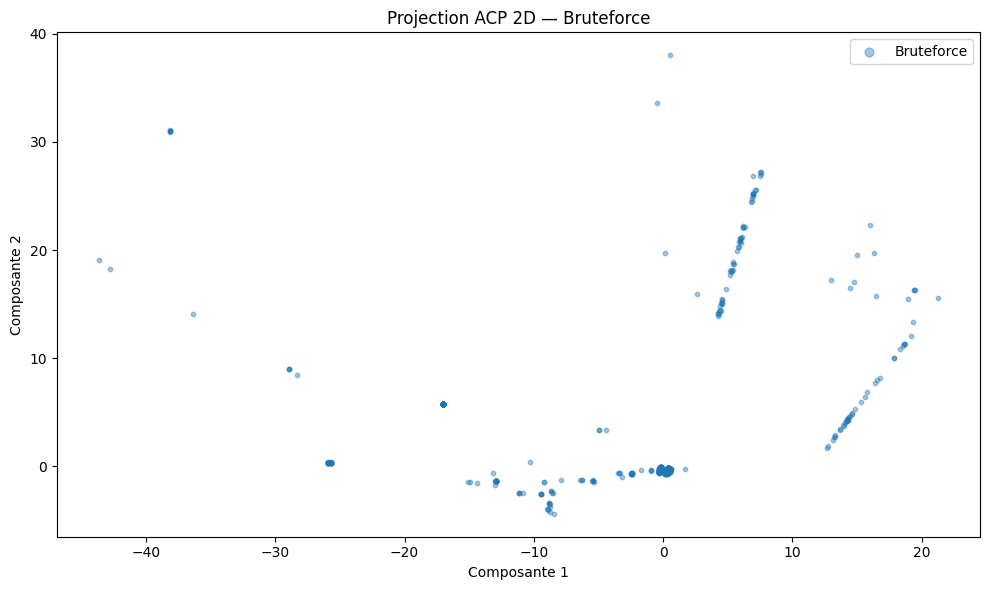

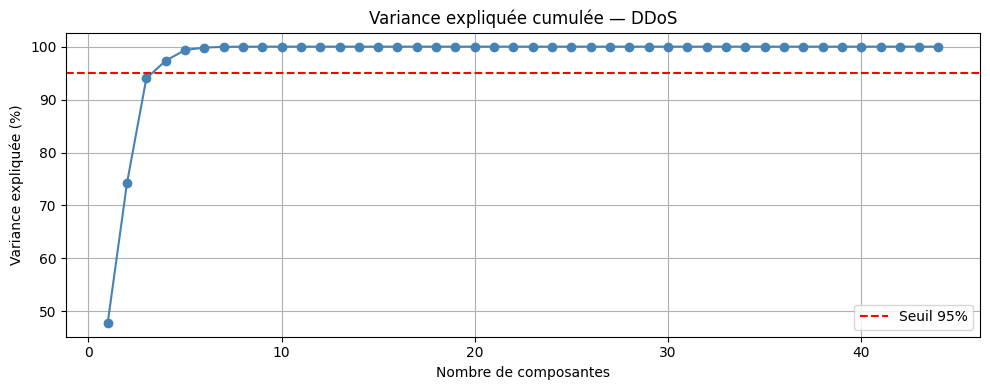

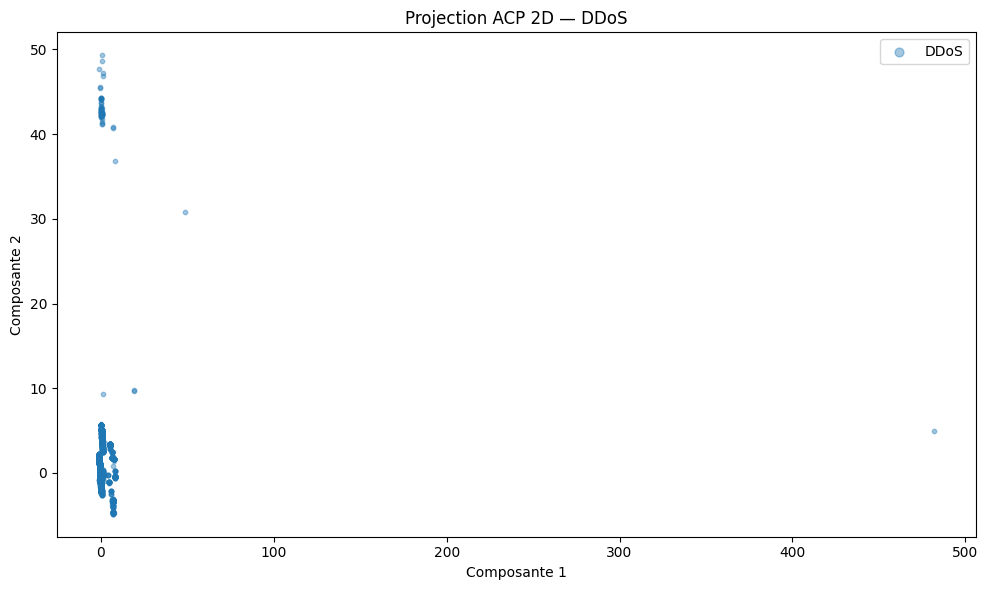

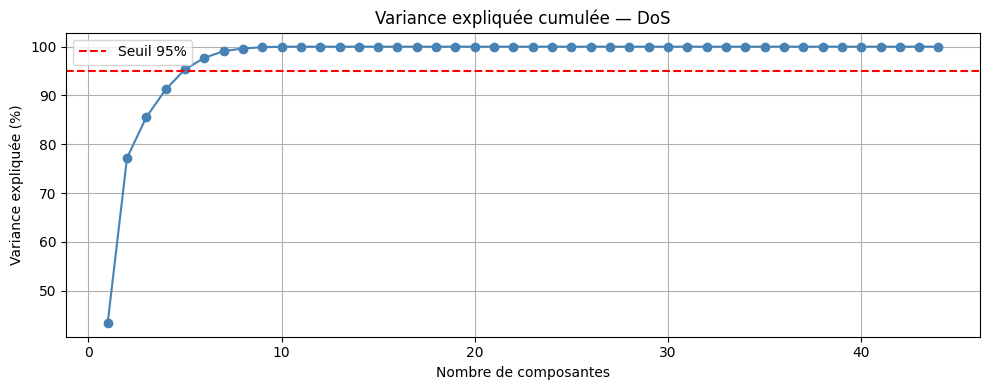

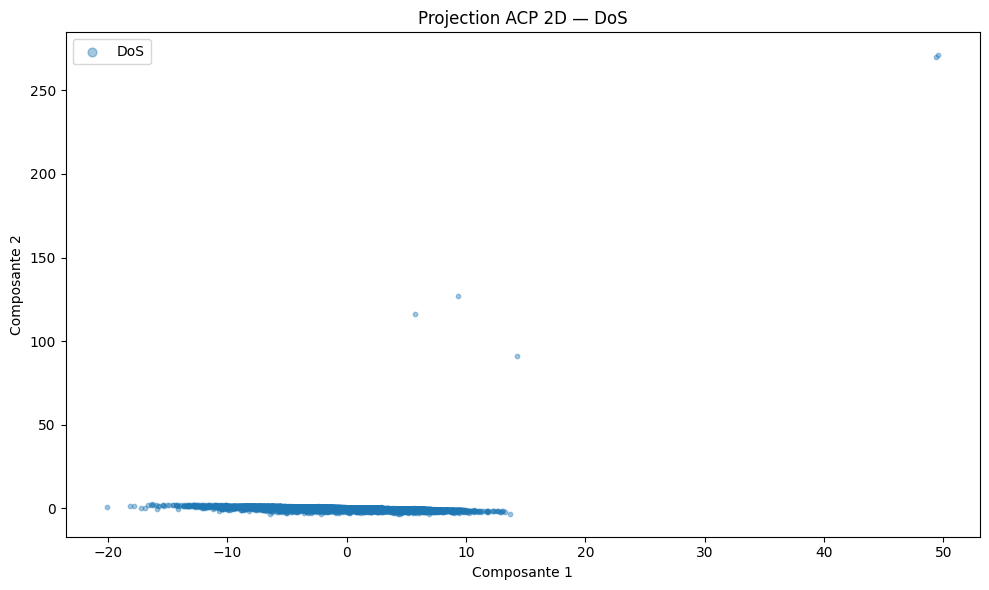

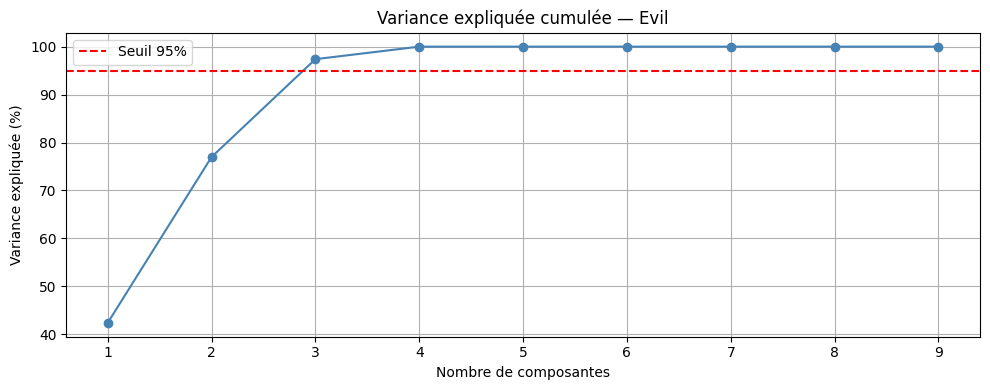

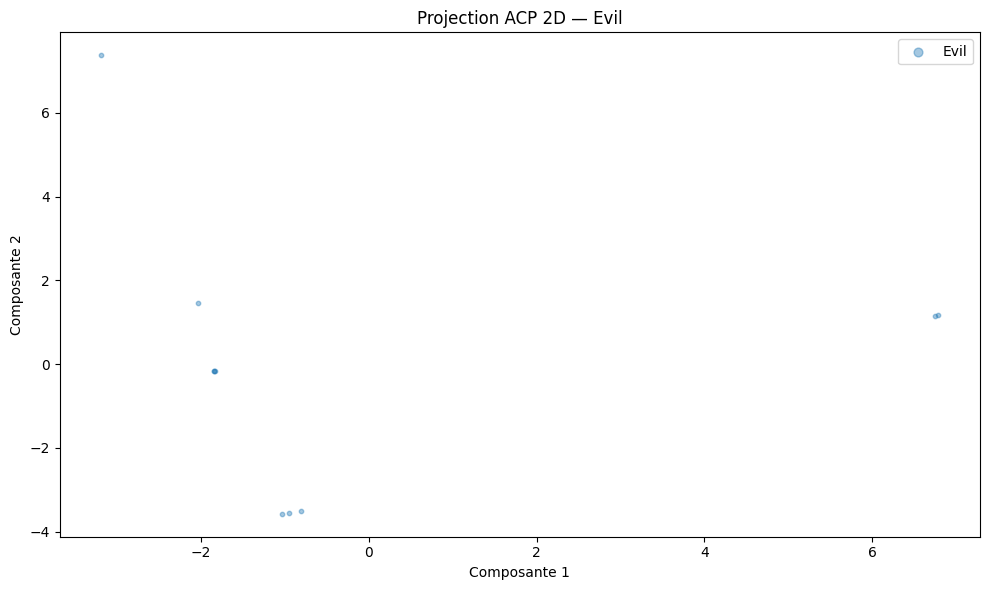

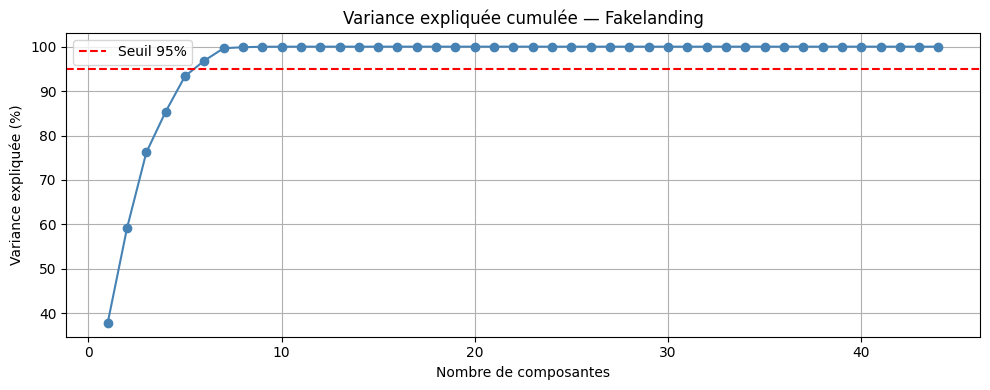

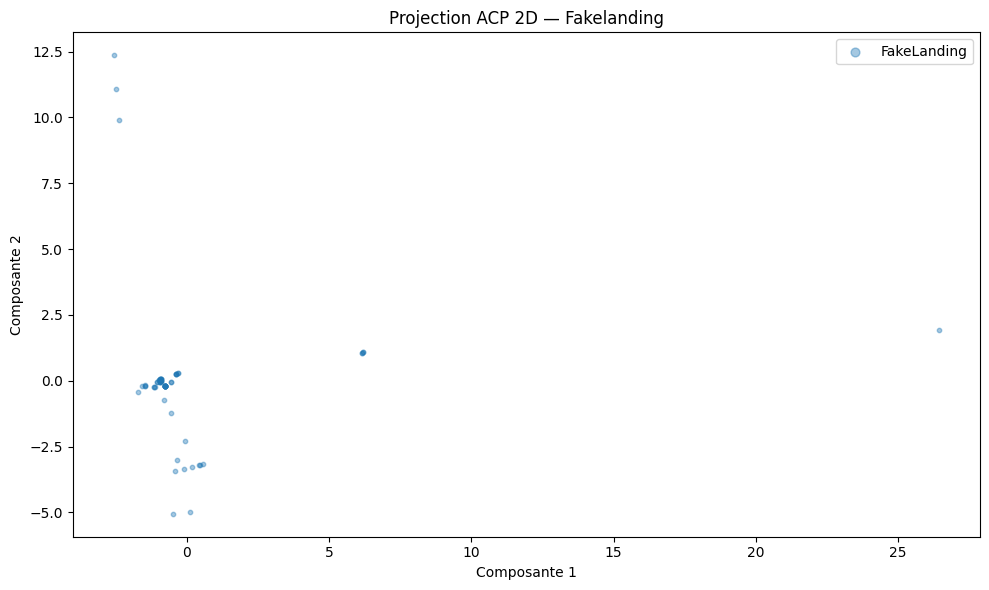

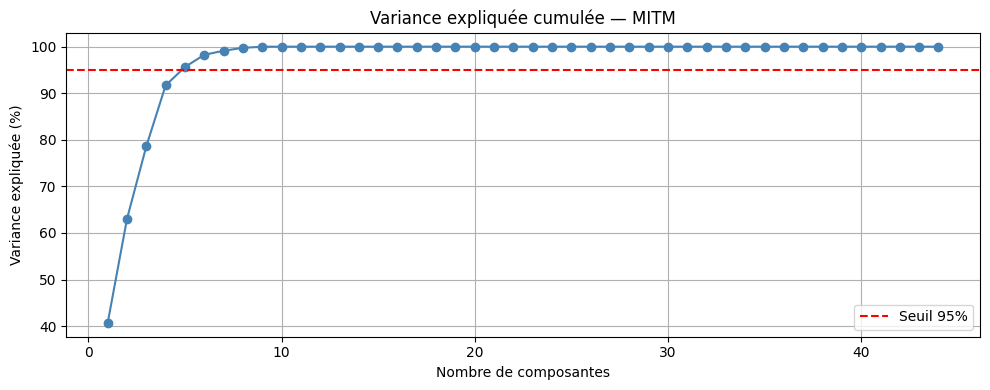

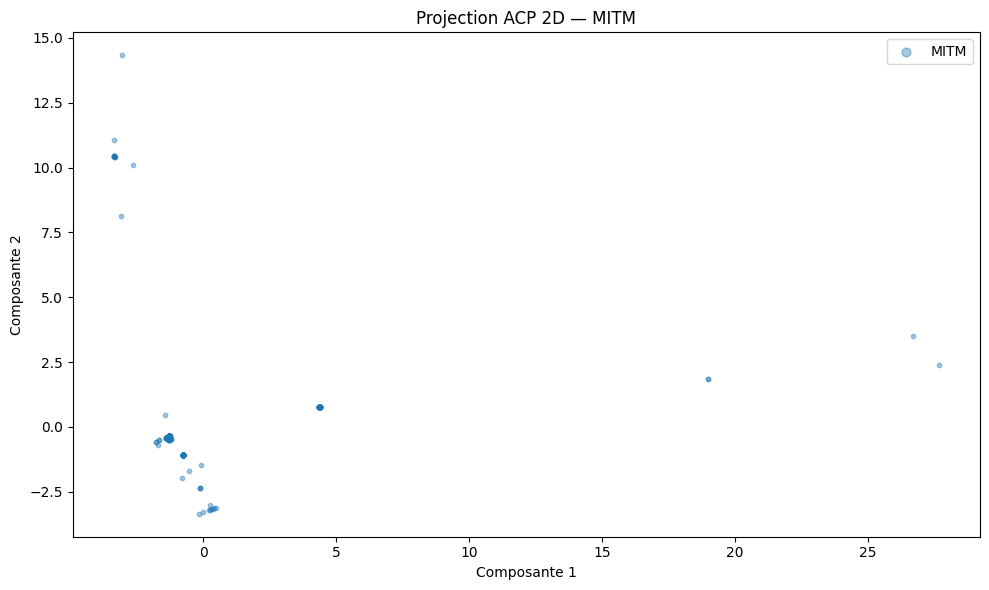

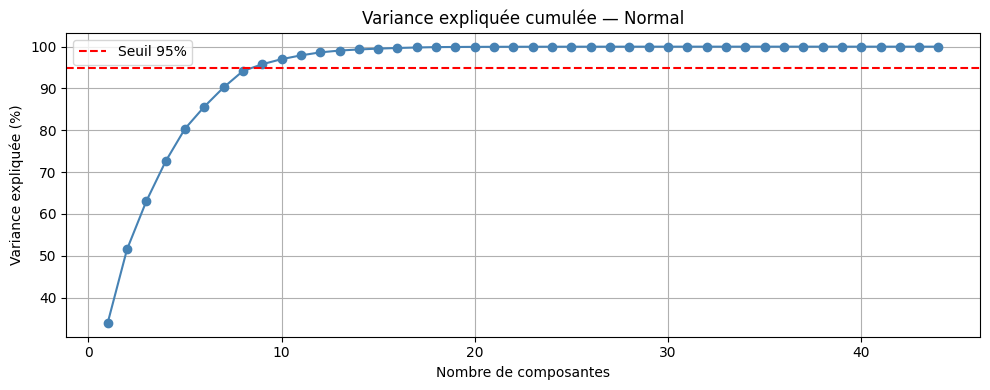

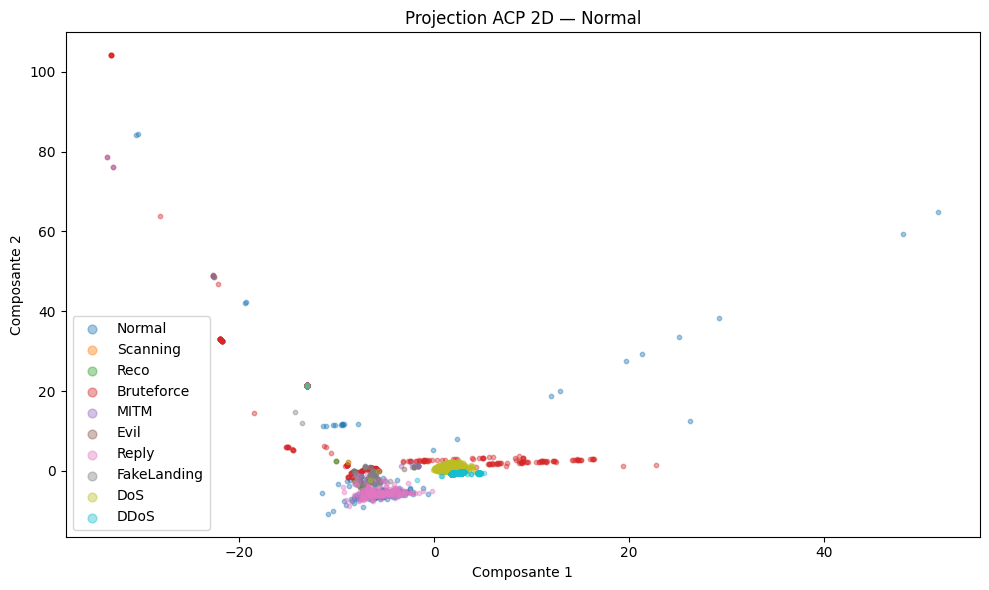

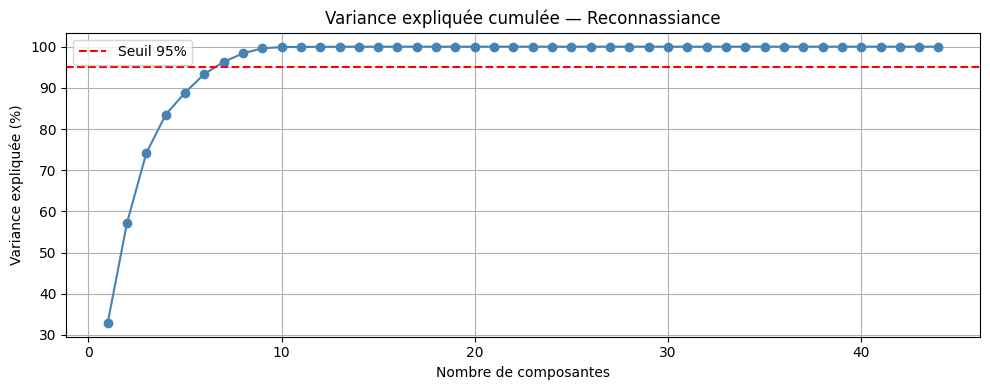

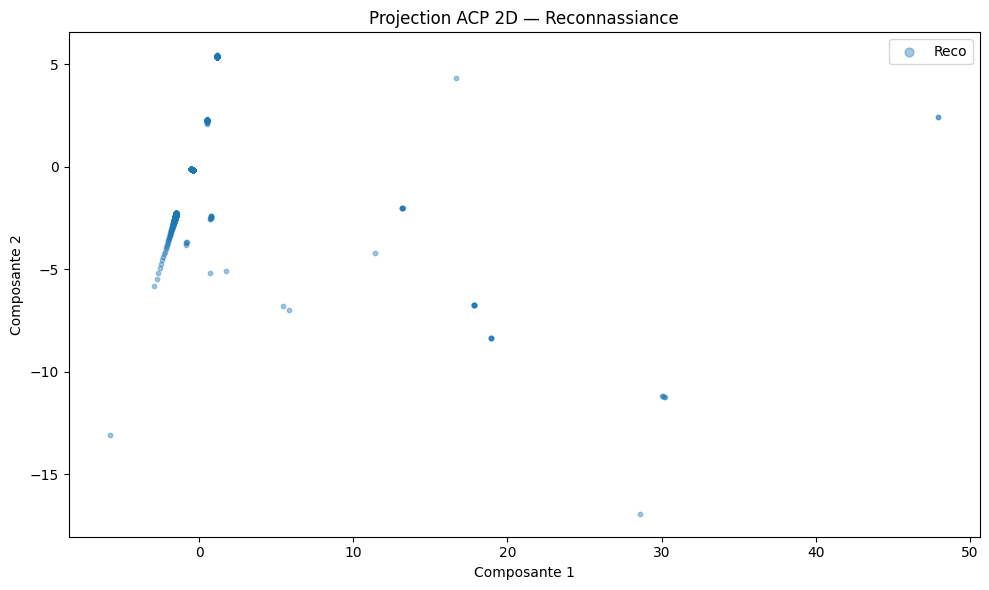

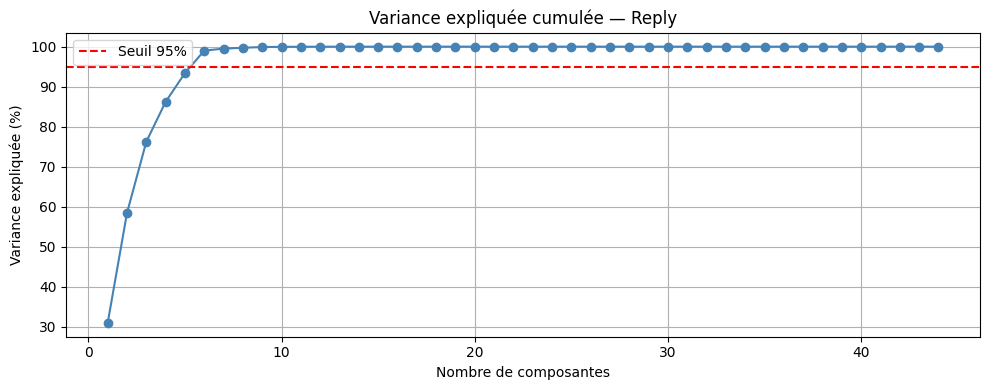

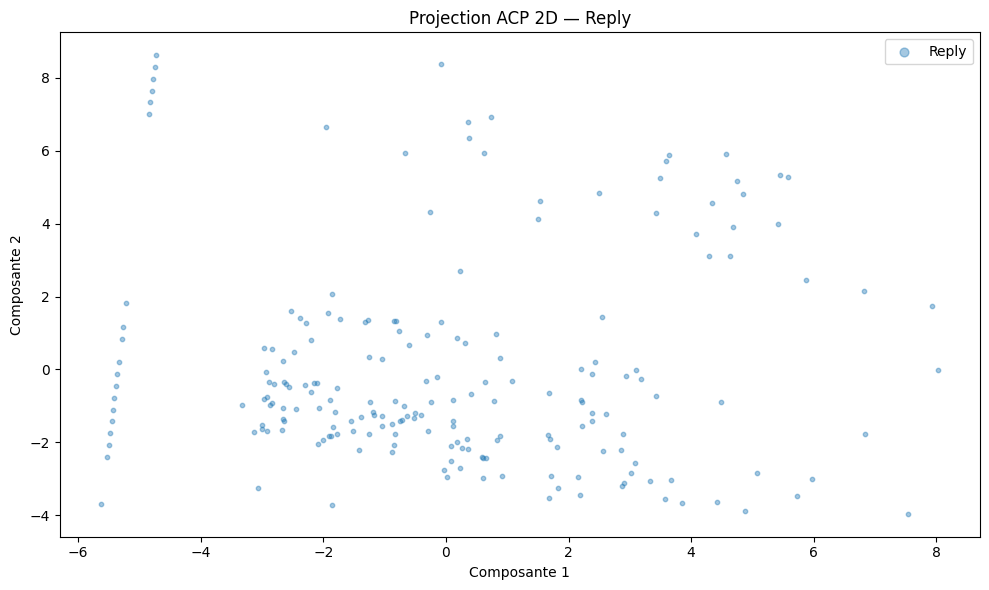

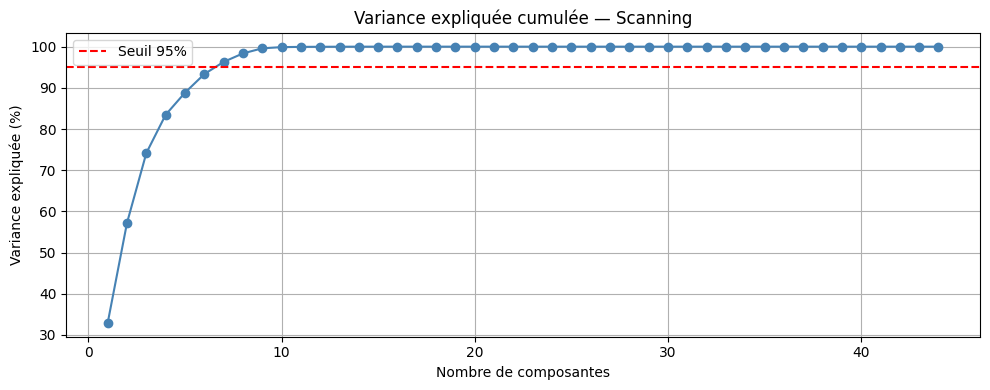

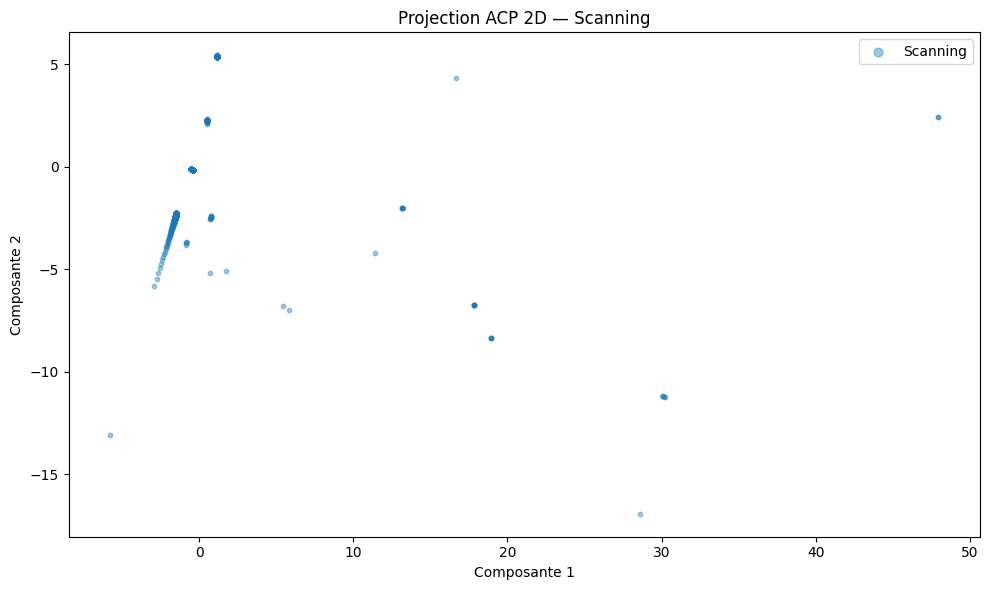

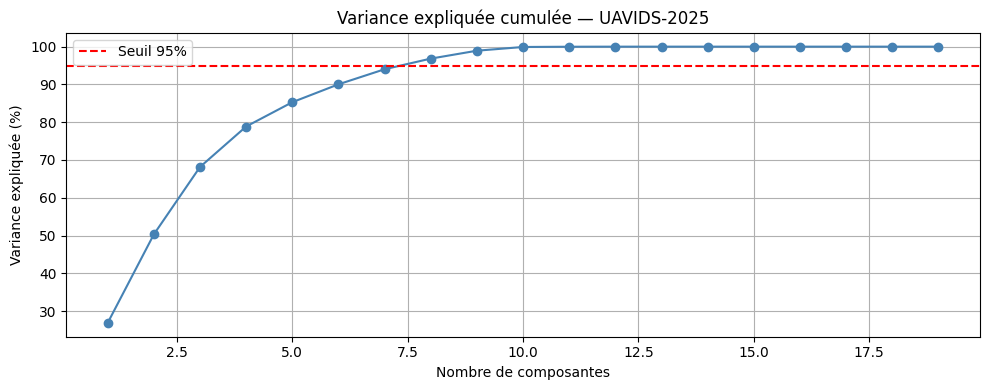

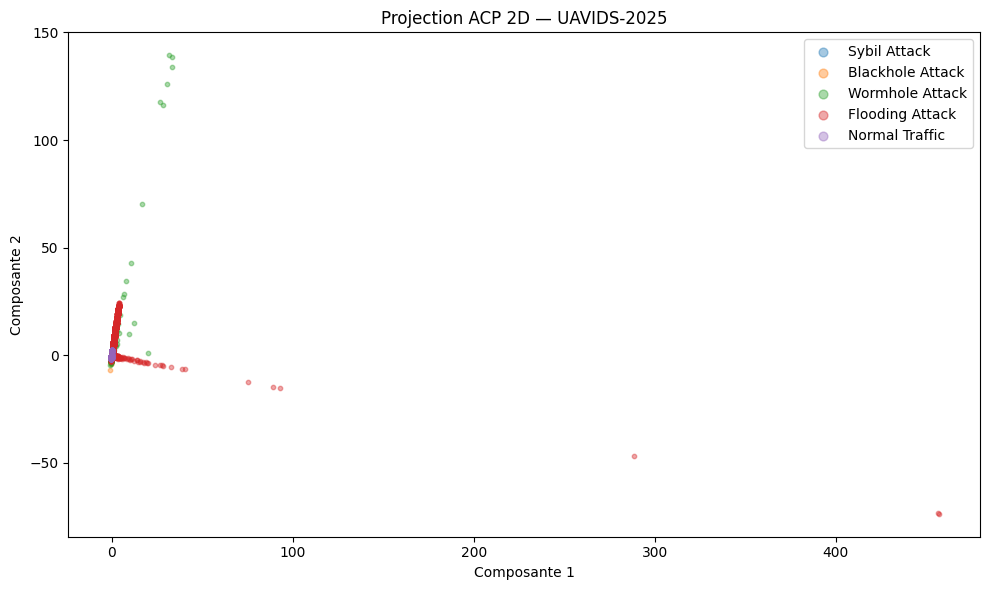


Documentation des datasets :
       Dataset  Lignes  Composantes  Nb_classes                                                                          Classes ACP_appliquee
    Bruteforce    5097            7           1                                                                       Bruteforce           Oui
          DDoS   14292            4           1                                                                             DDoS           Oui
           DoS   14121            5           1                                                                              DoS           Oui
          Evil      10            3           1                                                                             Evil           Oui
   Fakelanding      69            6           1                                                                      FakeLanding           Oui
          MITM     208            5           1                                                                 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Rechargement des données nettoyées
nettoyees_path = r"C:\Drone_Attack_Similarity_Project\DATASET\Nettoyées"
figures_path   = r"C:\Drone_Attack_Similarity_Project\Rapport\figures"
tables_path    = r"C:\Drone_Attack_Similarity_Project\Rapport\tables"
final_path     = r"C:\Drone_Attack_Similarity_Project\DATASET\Final"
os.makedirs(figures_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)
os.makedirs(final_path, exist_ok=True)

datasets_clean = {}
for filename in os.listdir(nettoyees_path):
    if filename.endswith("_clean.csv"):
        name = filename.replace("_clean.csv", "").replace("_", "-")
        datasets_clean[name] = pd.read_csv(f"{nettoyees_path}\\{filename}")

print("Datasets nettoyés chargés :")
for name, df in datasets_clean.items():
    print(f"  {name:<18} → {df.shape[0]} lignes, {df.shape[1]} colonnes")

######### Prétraitement — tous les datasets ########

datasets_final = {}

for name, df in datasets_clean.items():

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # 1. Encodage des variables catégorielles (sauf label)
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    cat_cols = [c for c in cat_cols if c != "label"]
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    if cat_cols:
        print(f"Colonnes encodées  : {cat_cols}")
    else:
        print(f"Aucune colonne catégorielle")

    # 2. Séparation features / label
    X = df.drop(columns=["label"])
    y = df["label"]

    # 3. Normalisation StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_features = X_scaled.shape[1]
    n_samples  = X_scaled.shape[0]

    # 4. ACP — adaptée selon le nombre de lignes
    if n_samples >= n_features:
        # Cas normal — ACP complète
        pca_full = PCA()
        pca_full.fit(X_scaled)
        variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_) * 100
        n_components = np.argmax(variance_cumulee >= 95) + 1
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_scaled)
        print(f"ACP normale        : {n_features} → {n_components} composantes (95% variance)")

    else:
        # Cas peu de lignes (ex: Evil Twin = 48 < 45 features)
        n_components_max = n_samples - 1
        pca_full = PCA(n_components=n_components_max)
        pca_full.fit(X_scaled)
        variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_) * 100
        idx = np.argmax(variance_cumulee >= 95)
        n_components = idx + 1 if variance_cumulee[idx] >= 95 else n_components_max
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_scaled)
        print(f"ACP limitée        : {n_features} → {n_components} composantes ({n_samples} lignes)")

    datasets_final[name] = {
        "X"           : X_pca,
        "y"           : y,
        "columns"     : [f"PC{i+1}" for i in range(n_components)],
        "n_components": n_components,
        "variance"    : variance_cumulee,
    }

######### Matrice de corrélation — tous les datasets ########

for name, df in datasets_clean.items():

    X_corr = df.drop(columns=["label"])

    if X_corr.shape[0] < 2:
        print(f"{name} → ignoré (trop peu de lignes)")
        continue

    plt.figure(figsize=(16, 12))
    sns.heatmap(X_corr.corr(), annot=False, cmap="coolwarm", center=0, linewidths=0.5)
    plt.title(f"Matrice de corrélation — {name}")
    plt.tight_layout()
    filename = name.replace("-", "_").replace("/", "_")
    plt.savefig(f"{figures_path}\\Matrice_de_correlation_{filename}.png", dpi=150)

    # Sauvegarde 
    if name == "UAVIDS-2025":
        plt.savefig(f"{figures_path}\\Matrice_de_correlation.png", dpi=150)

    plt.show()

print(" Matrices de corrélation exportées pour tous les datasets")

######### Graphiques ACP — tous les datasets ########

for name, data in datasets_final.items():

    variance_cumulee = data["variance"]
    filename = name.replace("-", "_").replace("/", "_")

    # ── Variance expliquée
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee,
             marker="o", color="steelblue")
    plt.axhline(y=95, color="red", linestyle="--", label="Seuil 95%")
    plt.title(f"Variance expliquée cumulée — {name}")
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{figures_path}\\ACP_variance_{filename}.png", dpi=150)
    plt.show()

    # ── Projection 2D
    if data["X"].shape[1] >= 2:
        plt.figure(figsize=(10, 6))
        for label in data["y"].unique():
            mask = data["y"] == label
            plt.scatter(data["X"][mask, 0], data["X"][mask, 1],
                        label=label, alpha=0.4, s=10)
        plt.title(f"Projection ACP 2D — {name}")
        plt.xlabel("Composante 1")
        plt.ylabel("Composante 2")
        plt.legend(loc="best", markerscale=2)
        plt.tight_layout()
        plt.savefig(f"{figures_path}\\ACP_2D_{filename}.png", dpi=150)
        plt.show()

######### Documentation ########

doc_rows = []
for name, data in datasets_final.items():
    doc_rows.append({
        "Dataset"      : name,
        "Lignes"       : data["X"].shape[0],
        "Composantes"  : data["n_components"],
        "Nb_classes"   : len(data["y"].unique()),
        "Classes"      : ", ".join(data["y"].unique().astype(str)),
        "ACP_appliquee": "Oui",
    })

doc_df = pd.DataFrame(doc_rows)
doc_df.to_csv(f"{tables_path}\\documentation_datasets.csv", index=False)
print("\nDocumentation des datasets :")
print(doc_df.to_string(index=False))

######### Sauvegarde des données finales ########

for name, data in datasets_final.items():
    filename = name.replace("-", "_").replace("/", "_")
    df_out = pd.DataFrame(data["X"], columns=data["columns"])
    df_out["label"] = data["y"].values
    df_out.to_csv(f"{final_path}\\{filename}_final.csv", index=False)

print("\n Tous les datasets sauvegardés dans DATASET/Final/")
print(" Documentation exportée dans Rapport/tables/")
print(" Figures exportées dans Rapport/figures/")